In [10]:
# Note: 
# 1. You need to be connected to the HKU network or HKU VPN to access the chenlin04 server.
# 2. Do not upload chenlin04_student_login.txt to any public repository, such as GitHub and LLMs.
# 3. Contact Boao (boaozhan@connect.hku.hk) for any questions related to accessing/using the LinkUp data.

## Imports

In [1]:
import pandas as pd
import requests
import clickhouse_connect
from collections import namedtuple
from tqdm import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.api import OLS,add_constant
import seaborn as sns

## DB Connection

In [2]:
class SimpleResult:
    def __init__(self, json_data):
        self.result_rows = json_data.get('data', [])
        self.column_names = [meta['name'] for meta in json_data.get('meta', [])]

class SimpleClient:
    def __init__(self, host, username, password, **kwargs):
        self.base_url = f"http://{host}:8123/"
        self.auth = {
            'user': username,
            'password': password
        }
        
    def query(self, query_string):
        params = self.auth.copy()
        # Use JSON format to get metadata (column names) easily
        params['query'] = query_string + " FORMAT JSON"
        
        response = requests.get(self.base_url, params=params)
        
        if response.status_code != 200:
            raise Exception(f"Query failed: {response.text}")
            
        return SimpleResult(response.json())

# Initialize the client
with open('chenlin04_student_login.txt', 'r') as f:
    conn_info = eval(f.read())
    try:
        # Try to connect with clickhouse first
        client = clickhouse_connect.get_client(**conn_info)
        print("Connected using standard clickhouse_connect")
    except Exception as e:
        # If it doesn't work out, use requests
        print(f"Standard connection failed: {e}")
        print("Falling back to SimpleClient (lightweight mode)...")
        client = SimpleClient(**conn_info)
        print("Connected using SimpleClient")

Connected using standard clickhouse_connect


## Helper functions

In [3]:
def read_sql(sql: str) -> pd.DataFrame:
    if client is None:
        raise ValueError("Client is not initialized. Please call connect to the database first.")
    res = client.query(sql)
    try:
        assert len(res.result_rows) > 0, 'No data returned from the query'
        return pd.DataFrame(res.result_rows, columns=res.column_names)
    except Exception as e:
        print(f'Failed to read the result into a dataframe: {e}')
        return pd.DataFrame()

In [67]:
def get_firm_nobs():
    id_mapping = read_sql("select company_id from fina4359_linkup_202603.company_id_compustat_identifiers")['company_id']
    firm_dates = list()
    for company_id in id_mapping:
        sql = f"""
        select min(created) as start_date, max(last_seen) as end_date from fina4359_linkup_202603.firm_{company_id}
        """
        firm_date = read_sql(sql)
        firm_date['company_id'] = company_id
        firm_dates.append(firm_date)
    firm_nobs = pd.concat(firm_dates)
    firm_nobs = firm_nobs.loc[~firm_nobs['company_id'].duplicated()]
    firm_nobs['start_date'] = pd.to_datetime(firm_nobs['start_date'],format='%Y-%m-%d')
    firm_nobs['end_date'] = pd.to_datetime(firm_nobs['end_date'],format='%Y-%m-%d')
    firm_nobs['duration'] = (firm_nobs['end_date'] - firm_nobs['start_date'])/timedelta(days=1)
    firm_nobs = firm_nobs.sort_values(by='duration',ascending=False)
    return firm_nobs

In [5]:
def get_cusip(company_id: int) -> str:
    sql = f"""
    select cusip from fina4359_linkup_202603.company_id_compustat_identifiers
    where company_id = {company_id}
    """
    cusip = read_sql(sql)['cusip'].values[0][:-1]
    return cusip
def get_daily_ret(company_id: int) -> pd.DataFrame:
    cusip = get_cusip(company_id)
    sql = f"""
    select * from fina4359_linkup_202603.crsp_daily_ret_all_firms_since_2000
    where CUSIP = '{cusip}' and date >= 20100101
    """
    daily_ret = read_sql(sql)
    daily_ret = daily_ret.loc[daily_ret['date'].drop_duplicates().index]
    daily_ret['company_id'] = company_id
    daily_ret['ts'] = pd.to_datetime(daily_ret['date'],format='%Y%m%d')
    daily_ret['RET'] = daily_ret['RET'].replace('C',np.nan).astype(float)
    daily_ret['RETX'] = daily_ret['RETX'].replace('C',np.nan).astype(float)
    daily_ret = daily_ret.set_index(['company_id','ts'])
    return daily_ret

In [6]:
def get_hash_series(company_id: int) -> pd.DataFrame:
    sql = f"""
    select hash, created, last_seen 
    from fina4359_linkup_202603.firm_{company_id}
    """
    hash_tbl = read_sql(sql)
    hash_tbl['created'] = pd.to_datetime(hash_tbl['created'], format='%Y-%m-%d')
    hash_tbl['last_seen'] = pd.to_datetime(hash_tbl['last_seen'], format='%Y-%m-%d')
    hash_tbl['hash'] = hash_tbl['hash'].astype(str)

    # Determine the overall span of hash posting dates for the company.
    start_date = hash_tbl['created'].min()
    end_date = hash_tbl['last_seen'].max()
    snapshot_dates = pd.date_range(start=start_date, end=end_date, freq='D')
    snapshots = []

    # For each date in the posting span, find all job postings ("hash") active that day.
    for date in snapshot_dates:
        active_jobs = hash_tbl[(date >= hash_tbl['created']) & (date <= hash_tbl['last_seen'])].copy()
        if not active_jobs.empty:
            active_jobs['ts'] = date
            snapshots.append(active_jobs)

    if snapshots:
        hash_series = pd.concat(snapshots).sort_values(by='ts').reset_index(drop=True)
        hash_series['company_id'] = company_id
        hash_series = hash_series[['company_id', 'ts', 'hash']]
    else:
        # Return empty DataFrame with correct columns if no postings are found.
        hash_series = pd.DataFrame(columns=['company_id', 'ts', 'hash'])

    return hash_series

In [7]:
def get_job_attr(
    company_id: int,
) -> pd.DataFrame:
    sql = f"""
        select hash, onet, country, state, zip, created, last_updated, updates, last_seen, missing 
        from fina4359_linkup_202603.firm_{company_id}
    """
    attr_tbl = read_sql(sql)
    attr_tbl['onet'] = attr_tbl['onet'].fillna(-1).astype(int).astype(str).replace(-1,pd.NA)
    attr_tbl['country'] = attr_tbl['country'].fillna(-1).astype(int).astype(str).replace(-1,pd.NA)
    attr_tbl['state'] = attr_tbl['state'].fillna(-1).astype(int).astype(str).replace(-1,pd.NA)
    attr_tbl['created'] = pd.to_datetime(attr_tbl['created'], format='%Y-%m-%d')
    attr_tbl['missing'] = pd.to_datetime(attr_tbl['missing'], format='%Y-%m-%d')
    attr_tbl['hash'] = attr_tbl['hash'].astype(str)
    attr_tbl['last_updated'] = pd.to_datetime(attr_tbl['last_updated'], format='%Y-%m-%d')
    attr_tbl['last_seen'] = pd.to_datetime(attr_tbl['last_seen'], format='%Y-%m-%d')
    return attr_tbl

In [8]:
def get_job_des(
    company_id: int,
) -> pd.DataFrame:
    sql = f"""
        select hash, description from fina4359_linkup_202603.firm_{company_id}
    """
    des_tbl = read_sql(sql)
    des_tbl['hash'] = des_tbl['hash'].astype(str)
    des_tbl['description'] = des_tbl['description'].str.replace("\\n", "\n")
    return des_tbl

In [9]:
def plot_feat_by_ts(feat: pd.DataFrame):
    # Assuming index is MultiIndex (company_id, ts), drop company_id to plot aggregated over all companies
    feat_by_ts = feat.reset_index(level='company_id', drop=True)

    fig, axs = plt.subplots(len(feat_by_ts.columns), 1, figsize=(15, 3*len(feat_by_ts.columns)), sharex=True)
    if len(feat_by_ts.columns) == 1:
        axs = [axs]

    for i, col in enumerate(feat_by_ts.columns):
        axs[i].plot(feat_by_ts.index, feat_by_ts[col])
        axs[i].set_ylabel(col)
        axs[i].set_title(col)
    plt.xlabel('ts')
    plt.tight_layout()
    plt.show()
    
def plot_feat_target(X: pd.DataFrame, y: pd.Series):
    num_vars = X.shape[1]
    fig, axes = plt.subplots(nrows=(num_vars // 3) + (num_vars % 3 > 0), ncols=3, figsize=(12, num_vars))
    axes = axes.flatten()

    for i, col in enumerate(X.columns):
        ax = axes[i]
        x_vec = X[col]
        y_vec = y
        try:
            idx = x_vec.dropna().index.intersection(y_vec.dropna().index)
            x_vec = x_vec[idx]
            y_vec = y_vec[idx]
            n_obs = len(x_vec)
            if len(x_vec) == 0:
                ax.axis('off')
                continue
            # Fit regression using scipy.stats.linregress
            beta,intercept,corr,p_value,std_err = stats.linregress(x_vec, y_vec)
            r2 = corr ** 2
            # Scatter and trend
            ax.scatter(x_vec, y_vec, s=8, alpha=0.5)
            xx = np.linspace(x_vec.min(), x_vec.max(), 100)
            yy = beta * xx + intercept
            ax.plot(xx, yy, color='red')
            # Annotation
            textstr = f'beta = {beta:.3f}\ncorr = {corr:.2%}\n$R^2$ = {r2:.2%}\nn = {n_obs}'
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
                    verticalalignment='top', bbox={'boxstyle':'round', 'facecolor':'white', 'alpha':0.7})
        except Exception as e:
            print(f"Error fitting '{col}': {e}")
        finally:
            ax.set_title(f"y vs {col}")
            ax.set_xlabel(col)
            ax.set_ylabel(y_vec.name)
    # Remove empty subplots
    for i in range(num_vars, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
    
def plot_feat_target_bins(X: pd.DataFrame, y: pd.Series):
    num_vars = X.shape[1]
    fig, axes = plt.subplots(
        nrows=(num_vars // 3) + (num_vars % 3 > 0), 
        ncols=3, 
        figsize=(12, num_vars)
    )
    axes = axes.flatten()

    for i, col in enumerate(X.columns):
        ax = axes[i]
        x_vec = X[col]
        y_vec = y
        try:
            # Drop NaNs and align indices
            idx = x_vec.dropna().index.intersection(y_vec.dropna().index)
            x_vec = x_vec.loc[idx]
            y_vec = y_vec.loc[idx]
            n_obs = len(x_vec)
            if len(x_vec) == 0:
                ax.axis('off')
                continue

            # Bin x into 10 bins
            binned_df = pd.DataFrame({
                col:(x_vec.groupby('ts').rank(pct=True)*10).clip(upper=9)//1,
                'y':y_vec
            })
            binned_df = binned_df.groupby(['ts',col])['y'].mean()
            binned_df = binned_df.groupby(col).mean()
            binned_df = binned_df.reset_index()

            # Plot binned means as bars
            ax.bar(binned_df[col].values, binned_df['y'].values, width=(binned_df[col].max() - binned_df[col].min())/10 * 0.9, color='red', alpha=0.6, label='binned mean')
            ax.legend(fontsize=8)
        except Exception as e:
            print(f"Error in binning or fitting '{col}': {e}")
        finally:
            ax.set_title(f"y vs {col}")
            ax.set_xlabel(col)
            ax.set_ylabel(y_vec.name)
    # Remove empty subplots
    for i in range(num_vars, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

## EDA

### Data descriptions

In [68]:
all_tbls = read_sql("show tables from fina4359_linkup_202603")
all_tbls.head(5)

,name
0,company_id_compustat_identifiers
1,compustat_na_quarterly_all_firms_since_2000
2,country_state_code_mapping
3,crsp_daily_ret_all_firms_since_2000
4,crsp_monthly_ret_all_firms_since_2000


In [11]:
daily_ret = read_sql(
    """
    select * from fina4359_linkup_202603.crsp_daily_ret_all_firms_since_2000 
    where date >= 20100101
    order by CUSIP desc limit 100
    """
)
daily_ret.head(5)

,PERMNO,date,TICKER,COMNAM,PERMCO,CUSIP,DIVAMT,PRC,VOL,RET,OPENPRC,RETX
0,15857,20200609,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,10.04,320486.0,-0.005941,10.08,-0.005941
1,15857,20180223,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,50.75,122276.0,0.002964,51.00,0.002964
2,15857,20220916,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,3.22,813390.0,-0.041667,3.36,-0.041667
3,15857,20220915,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,3.36,129291.0,-0.045455,3.49,-0.045455
4,15857,20241226,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,13.48,418580.0,0.005220,13.26,0.005220


In [12]:
reg_mapping = read_sql("select * from fina4359_linkup_202603.country_state_code_mapping")
reg_mapping.head(5)

,country,state,country_name,state_name
0,0,0,None,None
1,0,1,None,CA
2,0,2,None,TX
3,0,3,None,FL
4,0,4,None,VA


In [13]:
id_mapping = read_sql("select * from fina4359_linkup_202603.company_id_compustat_identifiers")
id_mapping.head(5)

,company_id,cusip,gvkey,tic,conm,naics
0,20238,898402102,4685,TRMK,TRUSTMARK CORP,522110.0
1,43730,881569107,170969,TSRO,TESARO INC,325414.0
2,44223,539830109,6774,LMT,LOCKHEED MARTIN CORP,336414.0
3,12903,10948C107,33637,BV,BRIGHTVIEW HOLDINGS,541320.0
4,17378,38268T103,20644,GPRO,GOPRO INC,333316.0


In [14]:
sample_tbl = read_sql("select * from fina4359_linkup_202603.firm_10467 limit 100")
sample_tbl.head(5)

,hash,onet,country,state,zip,created,last_updated,updates,last_seen,missing,description
0,0489e44cfda10132c1061d8aeff1692d,15119909.0,1,24,97228.0,2016-10-08,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
1,094b60f6a344771862769e2570220e28,41203100.0,1,20,55122.0,2016-09-02,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
2,0c5fffb23fcf90bdb359d6f2046f0806,41203100.0,1,2,77429.0,2017-01-06,None,0,2017-01-29,2017-02-01,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
3,0a28eddba451425b131ff6d0413035f2,41203100.0,1,2,77502.0,2016-09-02,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
4,0b4fabe2406bdd38698a8c60a3e0e64d,27202100.0,1,4,10601.0,2016-10-04,None,0,2017-02-03,2017-02-05,Work Hard. Play Hard.


In [69]:
firm_nobs = get_firm_nobs()
firm_nobs.head(10)

,start_date,end_date,company_id,duration
0,2011-05-24,2022-10-03,23538,4150.0
0,2011-06-08,2022-10-03,18305,4135.0
0,2011-05-09,2022-06-23,23091,4063.0
0,2012-02-15,2022-10-03,19847,3883.0
0,2012-05-16,2022-10-03,20503,3792.0
0,2012-05-31,2022-10-02,24123,3776.0
0,2012-06-05,2022-10-03,370,3772.0
0,2012-06-26,2022-10-02,24921,3750.0
0,2012-07-19,2022-10-02,12247,3727.0
0,2012-08-10,2022-10-02,18257,3705.0


<Axes: ylabel='Frequency'>

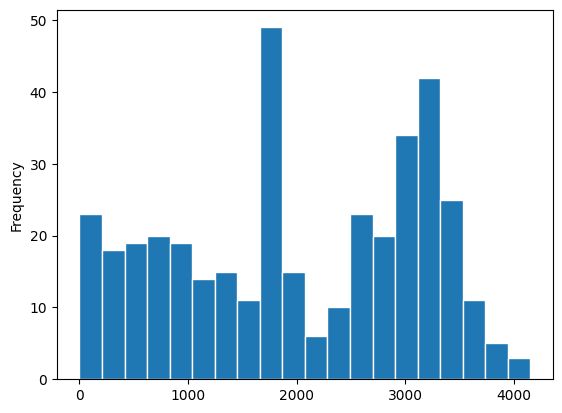

In [16]:
firm_nobs['duration'].plot(kind='hist',bins=20,edgecolor='white')

### Config

In [17]:
company_id = 24123
predict_horizon = 20

### Return

In [18]:
daily_ret = get_daily_ret(company_id)
daily_ret.head(5)

PERMNO      date TICKER            COMNAM  PERMCO  \
company_id ts                                                              
24123      2010-01-04   79758  20100104    BYD  BOYD GAMING CORP   29992   
           2010-01-05   79758  20100105    BYD  BOYD GAMING CORP   29992   
           2010-01-06   79758  20100106    BYD  BOYD GAMING CORP   29992   
           2010-01-07   79758  20100107    BYD  BOYD GAMING CORP   29992   
           2010-01-08   79758  20100108    BYD  BOYD GAMING CORP   29992   

                          CUSIP  DIVAMT   PRC        VOL       RET  OPENPRC  \
company_id ts                                                                 
24123      2010-01-04  10330410     NaN  8.60   743900.0  0.027479    8.430   
           2010-01-05  10330410     NaN  8.66  1679600.0  0.006977    8.690   
           2010-01-06  10330410     NaN  8.69   863000.0  0.003464    8.680   
           2010-01-07  10330410     NaN  8.79   831600.0  0.011508    8.660   
           2010-01-08  10330410     NaN  8.45  1345600.0 -0.038680    8.785   

                           RETX  
company_id ts                    
24123      2010-01-04  0.027479  
           2010-01-05  0.006977  
           2010-01-06  0.003464  
           2010-01-07  0.011508  
           2010-01-08 -0.038680

### Feature

In [19]:
# This creates a time series of active job postings
hash = get_hash_series(company_id)

In [20]:
# Can merge to hash to get the attributes of active job postings on each day
# can be slow and memory-intensive, especially for description
attr = get_job_attr(company_id) # attributes except description
des = get_job_des(company_id) # description

In [21]:
hash_attr = hash.merge(attr,on='hash',how='left')
hash_attr['lasting'] = (hash_attr['ts'] - hash_attr['created'])/timedelta(days=1)
hash_attr['region'] = hash_attr['country'].astype(str) + '_' + hash_attr['state'].astype(str)
hash_attr['onet_group'] = hash_attr['onet'].astype(str).str[:2]
hash_attr['onet_occupation'] = hash_attr['onet'].astype(str).str[2:6]
hash_attr['onet_specific'] = hash_attr['onet'].astype(str).str[6:]
hash_attr.head(5)

,company_id,ts,hash,onet,country,state,zip,created,last_updated,updates,last_seen,missing,lasting,region,onet_group,onet_occupation,onet_specific
0,24123,2012-05-31,f52c1489e47812177f87ef2a909d926f,39301100,1,35,39533.0,2012-05-31,NaT,0,2014-06-04,2014-06-08,0.0,1_35,39,3011,00
1,24123,2012-06-01,f52c1489e47812177f87ef2a909d926f,39301100,1,35,39533.0,2012-05-31,NaT,0,2014-06-04,2014-06-08,1.0,1_35,39,3011,00
2,24123,2012-06-02,f52c1489e47812177f87ef2a909d926f,39301100,1,35,39533.0,2012-05-31,NaT,0,2014-06-04,2014-06-08,2.0,1_35,39,3011,00
3,24123,2012-06-03,f52c1489e47812177f87ef2a909d926f,39301100,1,35,39533.0,2012-05-31,NaT,0,2014-06-04,2014-06-08,3.0,1_35,39,3011,00
4,24123,2012-06-04,f52c1489e47812177f87ef2a909d926f,39301100,1,35,39533.0,2012-05-31,NaT,0,2014-06-04,2014-06-08,4.0,1_35,39,3011,00


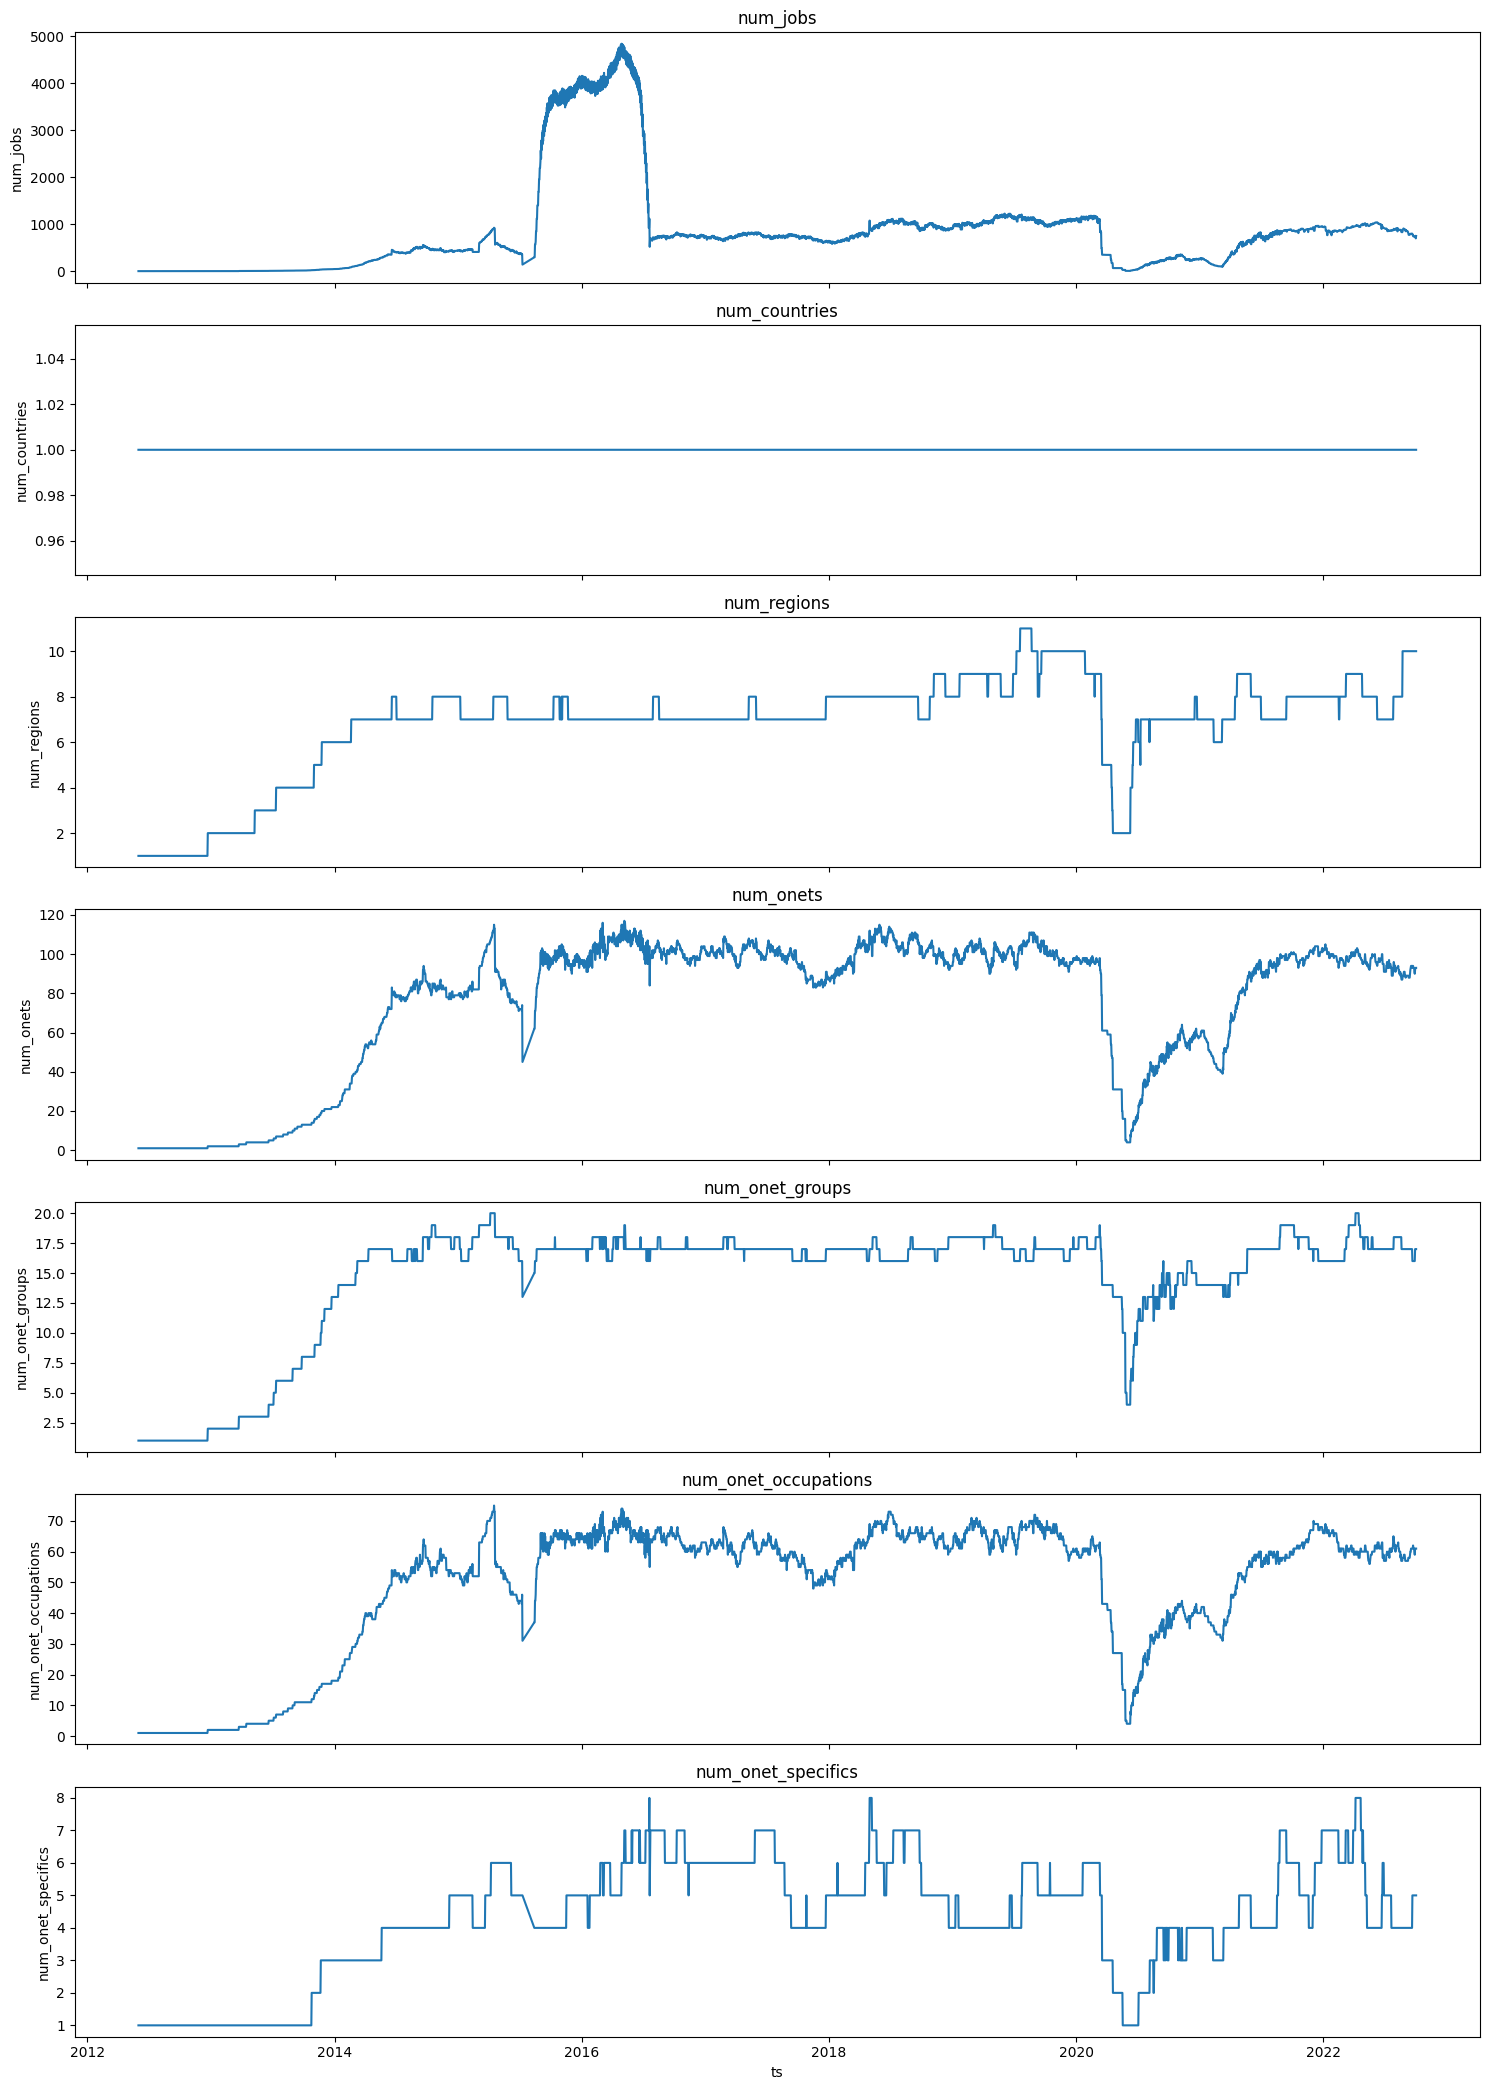

,num_jobs,num_countries,num_regions,num_onets,num_onet_groups,num_onet_occupations,num_onet_specifics
count,3742.000000,3742.0,3742.000000,3742.000000,3742.000000,3742.000000,3742.000000
mean,851.885623,1.0,6.780064,74.704971,14.554249,48.275521,4.285142
std,1000.182961,0.0,2.245670,36.111696,5.085542,21.972553,1.812425
min,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000
25%,239.000000,1.0,7.000000,54.000000,14.000000,39.000000,3.000000
50%,726.000000,1.0,7.000000,94.000000,17.000000,59.000000,4.000000
75%,966.500000,1.0,8.000000,100.000000,17.000000,64.000000,6.000000
max,4837.000000,1.0,11.000000,117.000000,20.000000,75.000000,8.000000


In [22]:
feat = hash_attr.groupby(['company_id','ts']).agg(
    num_jobs = ('hash','nunique'),
    num_countries = ('country','nunique'),
    num_regions = ('region','nunique'),
    num_onets = ('onet','nunique'),
    num_onet_groups = ('onet_group','nunique'),
    num_onet_occupations = ('onet_occupation','nunique'),
    num_onet_specifics = ('onet_specific','nunique'),
    #min_lasting = ('lasting','min'),
    #max_lasting = ('lasting','max'),
    #med_lasting = ('lasting','median'),
    #std_lasting = ('lasting','std'),
)
plot_feat_by_ts(feat)
feat.describe()

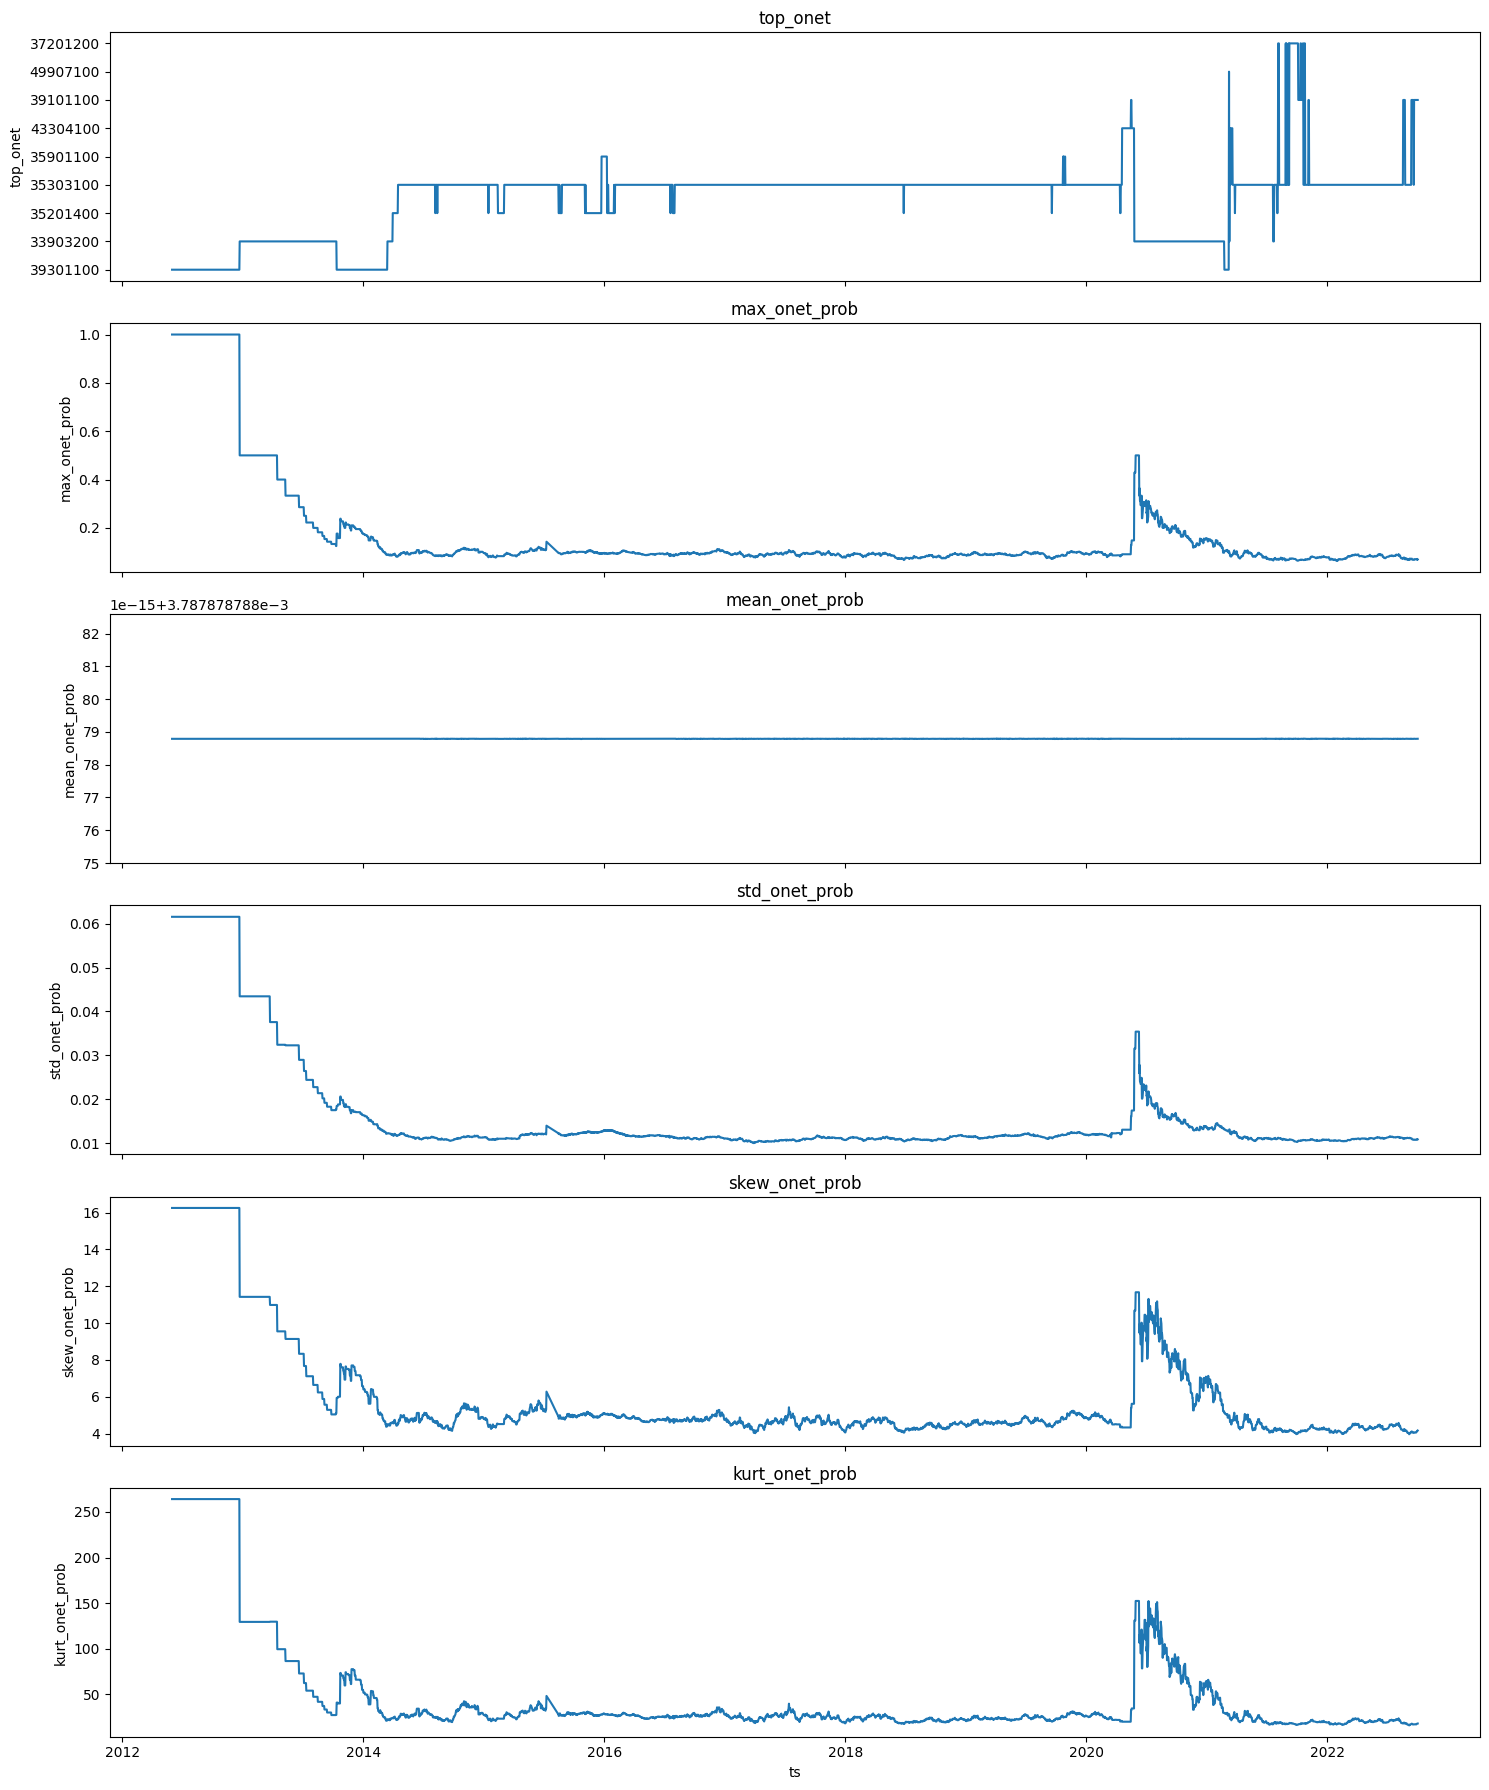

,max_onet_prob,mean_onet_prob,std_onet_prob,skew_onet_prob,kurt_onet_prob
count,3742.000000,3.742000e+03,3742.000000,3742.000000,3742.000000
mean,0.171832,3.787879e-03,0.016359,5.928142,48.238185
std,0.217789,2.145914e-18,0.012645,2.981405,58.346406
min,0.063702,3.787879e-03,0.010006,3.966408,16.066761
25%,0.086093,3.787879e-03,0.011007,4.488832,22.595767
50%,0.093960,3.787879e-03,0.011547,4.760226,26.461793
75%,0.113676,3.787879e-03,0.013058,5.319518,35.060303
max,1.000000,3.787879e-03,0.061546,16.248077,264.000000


In [23]:
onet_pivot = hash_attr.pivot_table(
    index=['company_id','ts'],
    columns='onet',
    values='hash',
    aggfunc='nunique',
    fill_value=0,
)
# normalize to get the probability of each occupation on each day
onet_pivot = onet_pivot.div(onet_pivot.sum(axis=1),axis=0)
onet_dist = pd.DataFrame({
    'top_onet': onet_pivot.idxmax(axis=1),
    'max_onet_prob': onet_pivot.max(axis=1),
    'mean_onet_prob': onet_pivot.mean(axis=1),
    'std_onet_prob': onet_pivot.std(axis=1),
    'skew_onet_prob': onet_pivot.skew(axis=1),
    'kurt_onet_prob': onet_pivot.kurt(axis=1),
})
plot_feat_by_ts(onet_dist)
onet_dist.describe()

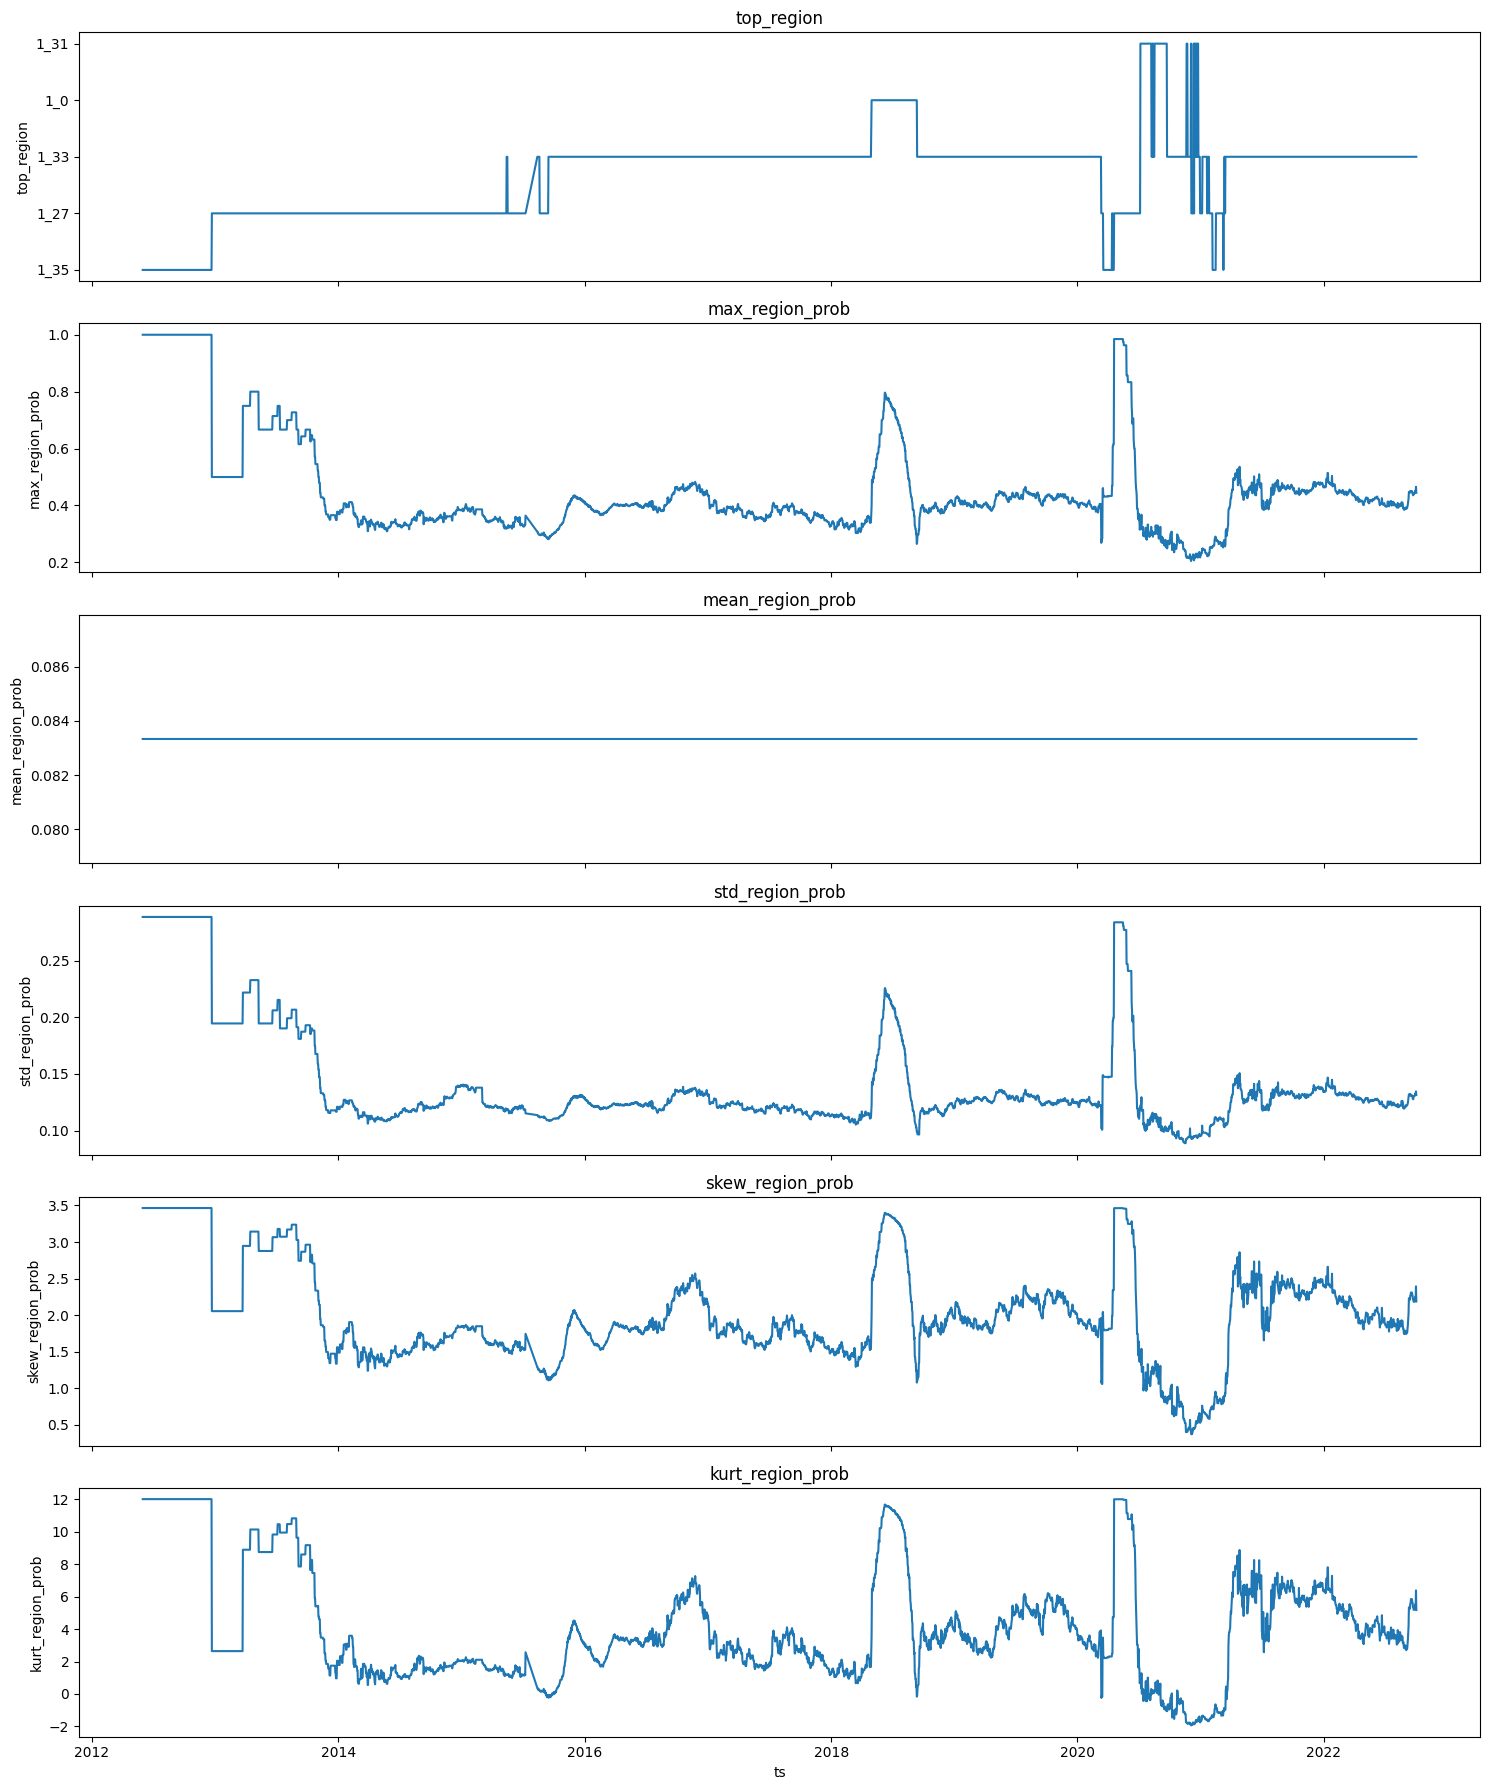

,max_region_prob,mean_region_prob,std_region_prob,skew_region_prob,kurt_region_prob
count,3742.000000,3.742000e+03,3742.000000,3742.000000,3742.000000
mean,0.455493,8.333333e-02,0.141943,2.011164,4.152524
std,0.177774,6.058584e-18,0.046962,0.659748,3.413547
min,0.204819,8.333333e-02,0.088870,0.372211,-1.934698
25%,0.359500,8.333333e-02,0.118365,1.611601,1.777437
50%,0.402668,8.333333e-02,0.124842,1.877003,3.329287
75%,0.458949,8.333333e-02,0.135809,2.303551,5.750827
max,1.000000,8.333333e-02,0.288675,3.464102,12.000000


In [24]:
region_pivot = hash_attr.pivot_table(
    index=['company_id','ts'],
    columns='region',
    values='hash',
    aggfunc='nunique',
    fill_value=0,
)
# normalize to get the probability of each state on each day
region_pivot = region_pivot.div(region_pivot.sum(axis=1),axis=0)
region_dist = pd.DataFrame({
    'top_region': region_pivot.idxmax(axis=1),
    'max_region_prob': region_pivot.max(axis=1),
    'mean_region_prob': region_pivot.mean(axis=1),
    'std_region_prob': region_pivot.std(axis=1),
    'skew_region_prob': region_pivot.skew(axis=1),
    'kurt_region_prob': region_pivot.kurt(axis=1),
})
plot_feat_by_ts(region_dist)
region_dist.describe()

### Correlation

In [25]:
y = daily_ret['RET'].ewm(span=predict_horizon,adjust=False).mean().shift(-predict_horizon)
X = pd.concat([feat,onet_dist,region_dist],axis=1).ewm(span=predict_horizon,adjust=False).mean()

<Axes: >

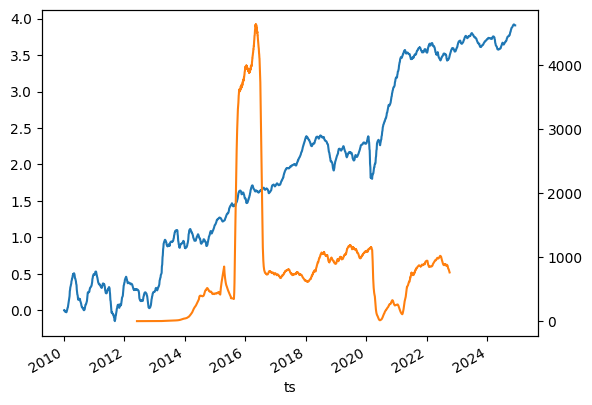

In [26]:
ax = y.droplevel(0).cumsum().plot(x='ts',y='RET')
X['num_jobs'].droplevel(0).plot(x='ts',y='num_jobs',secondary_y=True,ax=ax)

Error fitting 'num_countries': Cannot calculate a linear regression if all x values are identical
Error fitting 'mean_region_prob': Cannot calculate a linear regression if all x values are identical


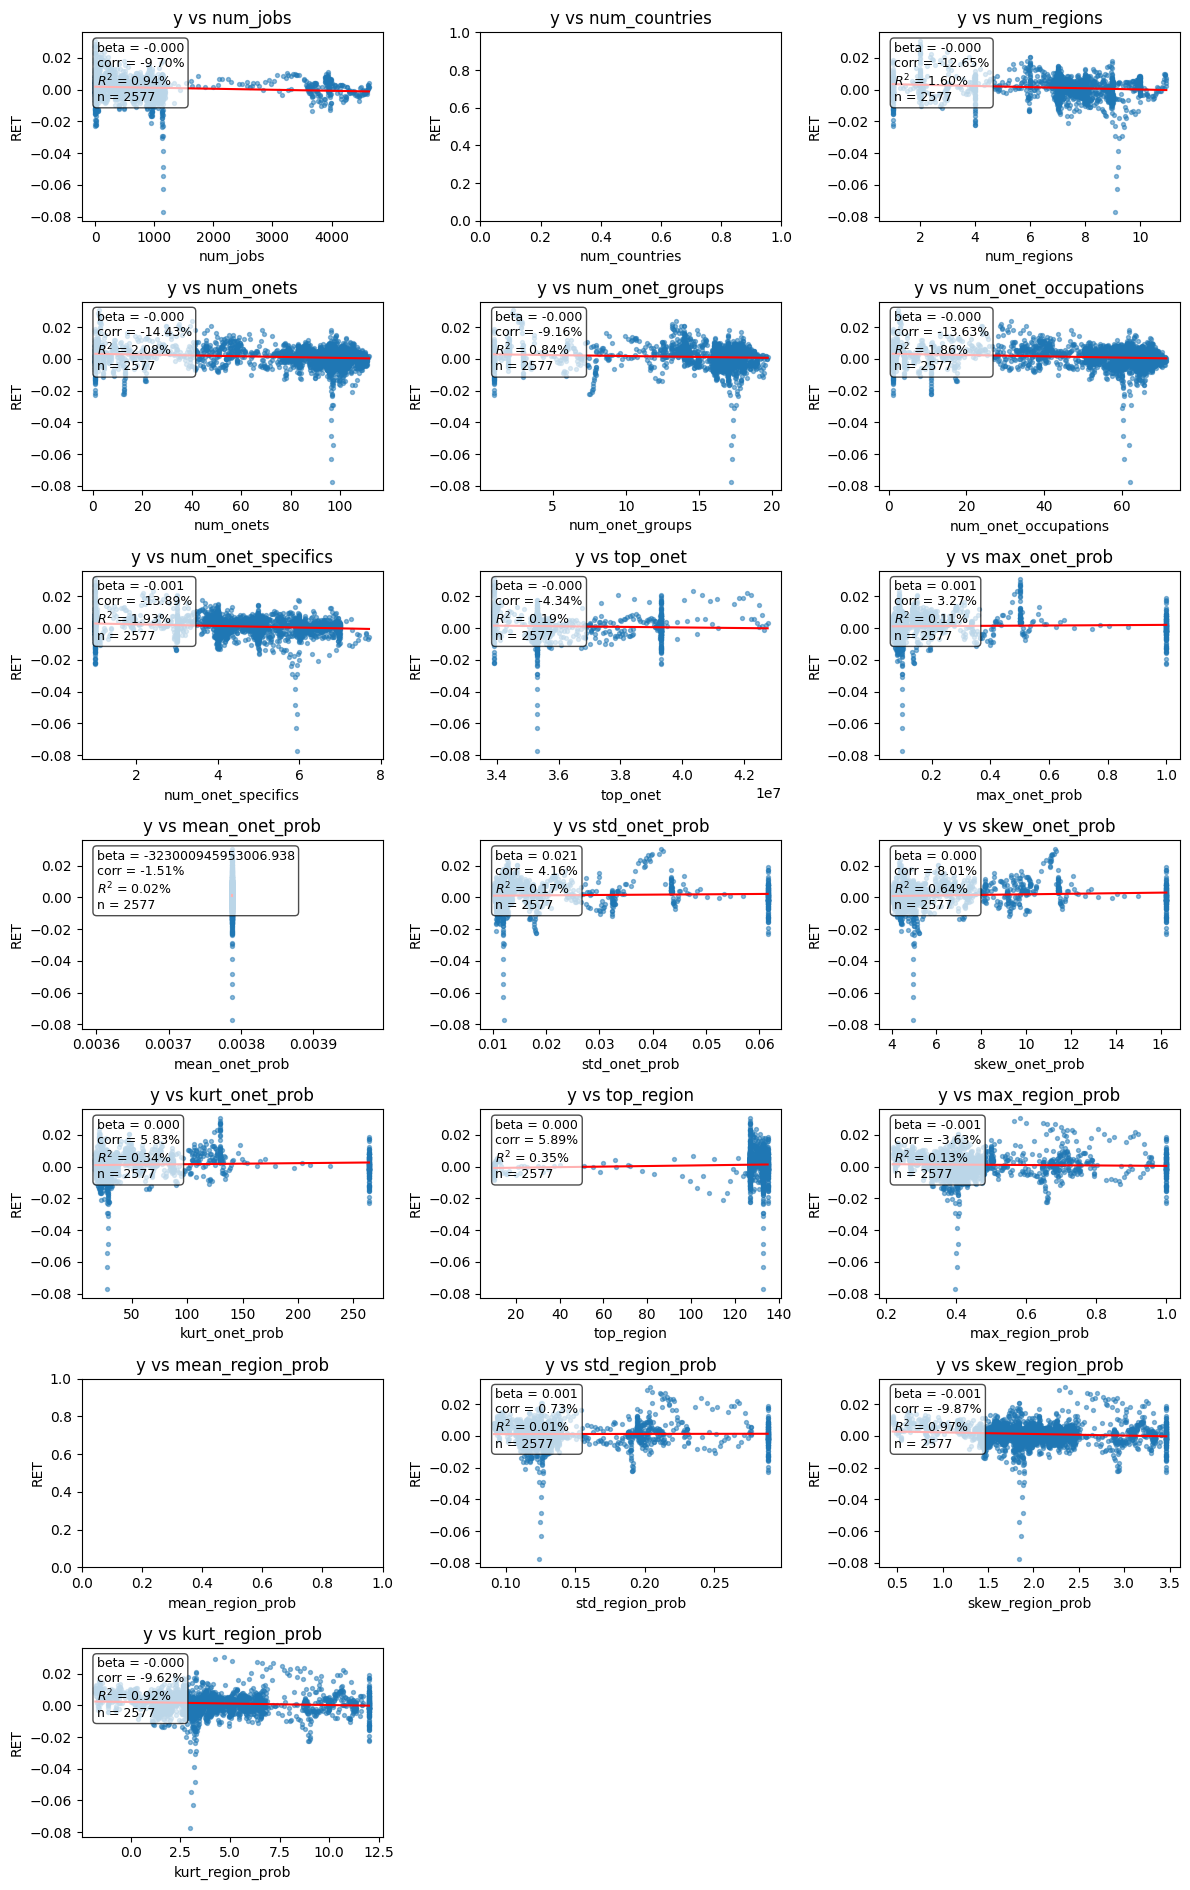

In [27]:
plot_feat_target(X,y)

## Dataset construction

### Batch download

In [ ]:
universe = firm_nobs[firm_nobs['duration'] > 1000]
dfs = list()

for company_id in tqdm(universe['company_id']):
    try:
        hash = get_hash_series(company_id)
        attr = get_job_attr(company_id)

        hash_attr = hash.merge(attr,on='hash',how='left')
        hash_attr['lasting'] = (hash_attr['ts'] - hash_attr['created'])/timedelta(days=1)
        hash_attr['region'] = hash_attr['country'].astype(str) + '_' + hash_attr['state'].astype(str)
        hash_attr['onet_group'] = hash_attr['onet'].astype(str).str[:2]
        hash_attr['onet_occupation'] = hash_attr['onet'].astype(str).str[2:6]
        hash_attr['onet_specific'] = hash_attr['onet'].astype(str).str[6:]

        feat = hash_attr.groupby(['company_id','ts']).agg(
            num_jobs = ('hash','nunique'),
            num_countries = ('country','nunique'),
            num_regions = ('region','nunique'),
            num_onets = ('onet','nunique'),
            num_onet_groups = ('onet_group','nunique'),
            num_onet_occupations = ('onet_occupation','nunique'),
            num_onet_specifics = ('onet_specific','nunique'),
            #min_lasting = ('lasting','min'),
            #max_lasting = ('lasting','max'),
            #med_lasting = ('lasting','median'),
            #std_lasting = ('lasting','std'),
        )
        onet_pivot = hash_attr.pivot_table(
            index=['company_id','ts'],
            columns='onet',
            values='hash',
            aggfunc='nunique',
            fill_value=0,
        )
        # normalize to get the probability of each occupation on each day
        onet_pivot = onet_pivot.div(onet_pivot.sum(axis=1),axis=0)
        onet_dist = pd.DataFrame({
            'top_onet': onet_pivot.idxmax(axis=1),
            'max_onet_prob': onet_pivot.max(axis=1),
            'mean_onet_prob': onet_pivot.mean(axis=1),
            'std_onet_prob': onet_pivot.std(axis=1),
            'skew_onet_prob': onet_pivot.skew(axis=1),
            'kurt_onet_prob': onet_pivot.kurt(axis=1),
        })
        region_pivot = hash_attr.pivot_table(
            index=['company_id','ts'],
            columns='region',
            values='hash',
            aggfunc='nunique',
            fill_value=0,
        )
        # normalize to get the probability of each state on each day
        region_pivot = region_pivot.div(region_pivot.sum(axis=1),axis=0)
        region_dist = pd.DataFrame({
            'top_region': region_pivot.idxmax(axis=1),
            'max_region_prob': region_pivot.max(axis=1),
            'mean_region_prob': region_pivot.mean(axis=1),
            'std_region_prob': region_pivot.std(axis=1),
            'skew_region_prob': region_pivot.skew(axis=1),
            'kurt_region_prob': region_pivot.kurt(axis=1),
        })
        
        daily_ret = get_daily_ret(company_id)

        y = daily_ret['RET']
        X = pd.concat([feat,onet_dist,region_dist],axis=1)
        df = pd.concat([y,X],axis=1)
        dfs.append(df)
    except Exception as e:
        print(f'{company_id} failed to construct the dataset: {e}')

df = pd.concat(dfs)

  1%|          | 2/281 [00:15<38:03,  8.19s/it]

Failed to read the result into a dataframe: No data returned from the query
18305 failed to construct the dataset: 'date'


  3%|▎         | 9/281 [02:00<1:06:53, 14.76s/it]

In [ ]:
completion_rate = universe['company_id'].isin(df.index.get_level_values(0).unique()).mean()
print(f'Completion rate: {completion_rate:.2%}')

Completion rate: 86.67%


In [ ]:
df.to_parquet('data/job/job_dataset.parquet')

## Regression modelling

In [28]:
df = pd.read_parquet('data/job/job_dataset.parquet')

In [52]:
model_df = df.dropna()
model_df = model_df.drop(columns=['top_onet','top_region'])

### Transformation

In [53]:
predict_horizon = 5

In [62]:
obj = firm_nobs['company_id']
print(obj.index.is_unique, obj.index.duplicated().sum())
print(obj.index[obj.index.duplicated()].unique()[:20])  # sample of duplicated keys

False 381
Index([0], dtype='int64')


In [65]:
firm_nobs[firm_nobs['company_id'].duplicated()]

,start_date,end_date,company_id,duration
0,2013-09-30,2022-10-03,12759,3290.0
0,2013-12-12,2022-10-03,29135,3217.0
0,2014-07-29,2022-10-02,35241,2987.0
0,2017-08-02,2022-10-03,43378,1888.0
0,2021-02-02,2022-10-03,68181,608.0


In [58]:
model_df.loc[(12759, '2013-09-30')]

C:\Users\user\AppData\Local\Temp\ipykernel_24060\2111952600.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  model_df.loc[(12759, '2013-09-30')]


,RET,num_jobs,num_countries,num_regions,num_onets,num_onet_groups,num_onet_occupations,num_onet_specifics,max_onet_prob,mean_onet_prob,std_onet_prob,skew_onet_prob,kurt_onet_prob,max_region_prob,mean_region_prob,std_region_prob,skew_region_prob,kurt_region_prob
ts,,,,,,,,,,,,,,,,,,
2013-09-30,-0.006915,7.0,1.0,5.0,6.0,4.0,6.0,2.0,0.285714,0.004425,0.028225,7.07977,55.192505,0.285714,0.006211,0.036936,6.441473,43.146369
2013-09-30,-0.006915,7.0,1.0,5.0,6.0,4.0,6.0,2.0,0.285714,0.004425,0.028225,7.07977,55.192505,0.285714,0.006211,0.036936,6.441473,43.146369


In [56]:
clip_min = 1e-2
clip_max = 1-1e-2

for col in model_df.columns:
    if col != 'RET':
        model_df[col] = model_df.groupby('company_id',group_keys=False)[col].apply(
            lambda s: (
                np.log(s).diff().ewm(min_periods=predict_horizon,span=predict_horizon,adjust=False).mean() 
            )
        )

model_df = model_df.groupby('ts',group_keys=False).rank(pct=True)
model_df = model_df.groupby('company_id',group_keys=False).apply(
    lambda df: df.ewm(min_periods=predict_horizon,span=predict_horizon,adjust=False).mean()
)
model_df = model_df.dropna()
model_df = model_df.clip(clip_min,clip_max)
model_df = model_df.apply(stats.norm.ppf)

ValueError: cannot handle a non-unique multi-index!

In [377]:
model_df['RET'] = model_df.groupby('company_id',group_keys=False)['RET'].shift(-predict_horizon)
model_df = model_df.dropna()

<Axes: ylabel='Frequency'>

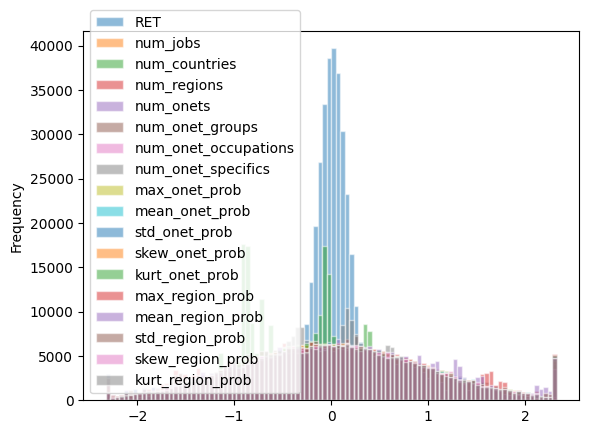

In [32]:
model_df.plot(kind='hist',bins=100,edgecolor='white',alpha=0.5)

### Cross section explanation

In [33]:
ts = model_df.index.get_level_values(1)
hi = ts.max()
lo = ts.min()
mid = lo + (hi - lo) / 2

train_df = model_df[model_df.index.get_level_values(1) < mid]
test_df = model_df[model_df.index.get_level_values(1) >= mid]

In [34]:
x_train = train_df.drop(columns=['RET'])
y_train = train_df['RET']

x_test = test_df.drop(columns=['RET'])
y_test = test_df['RET']

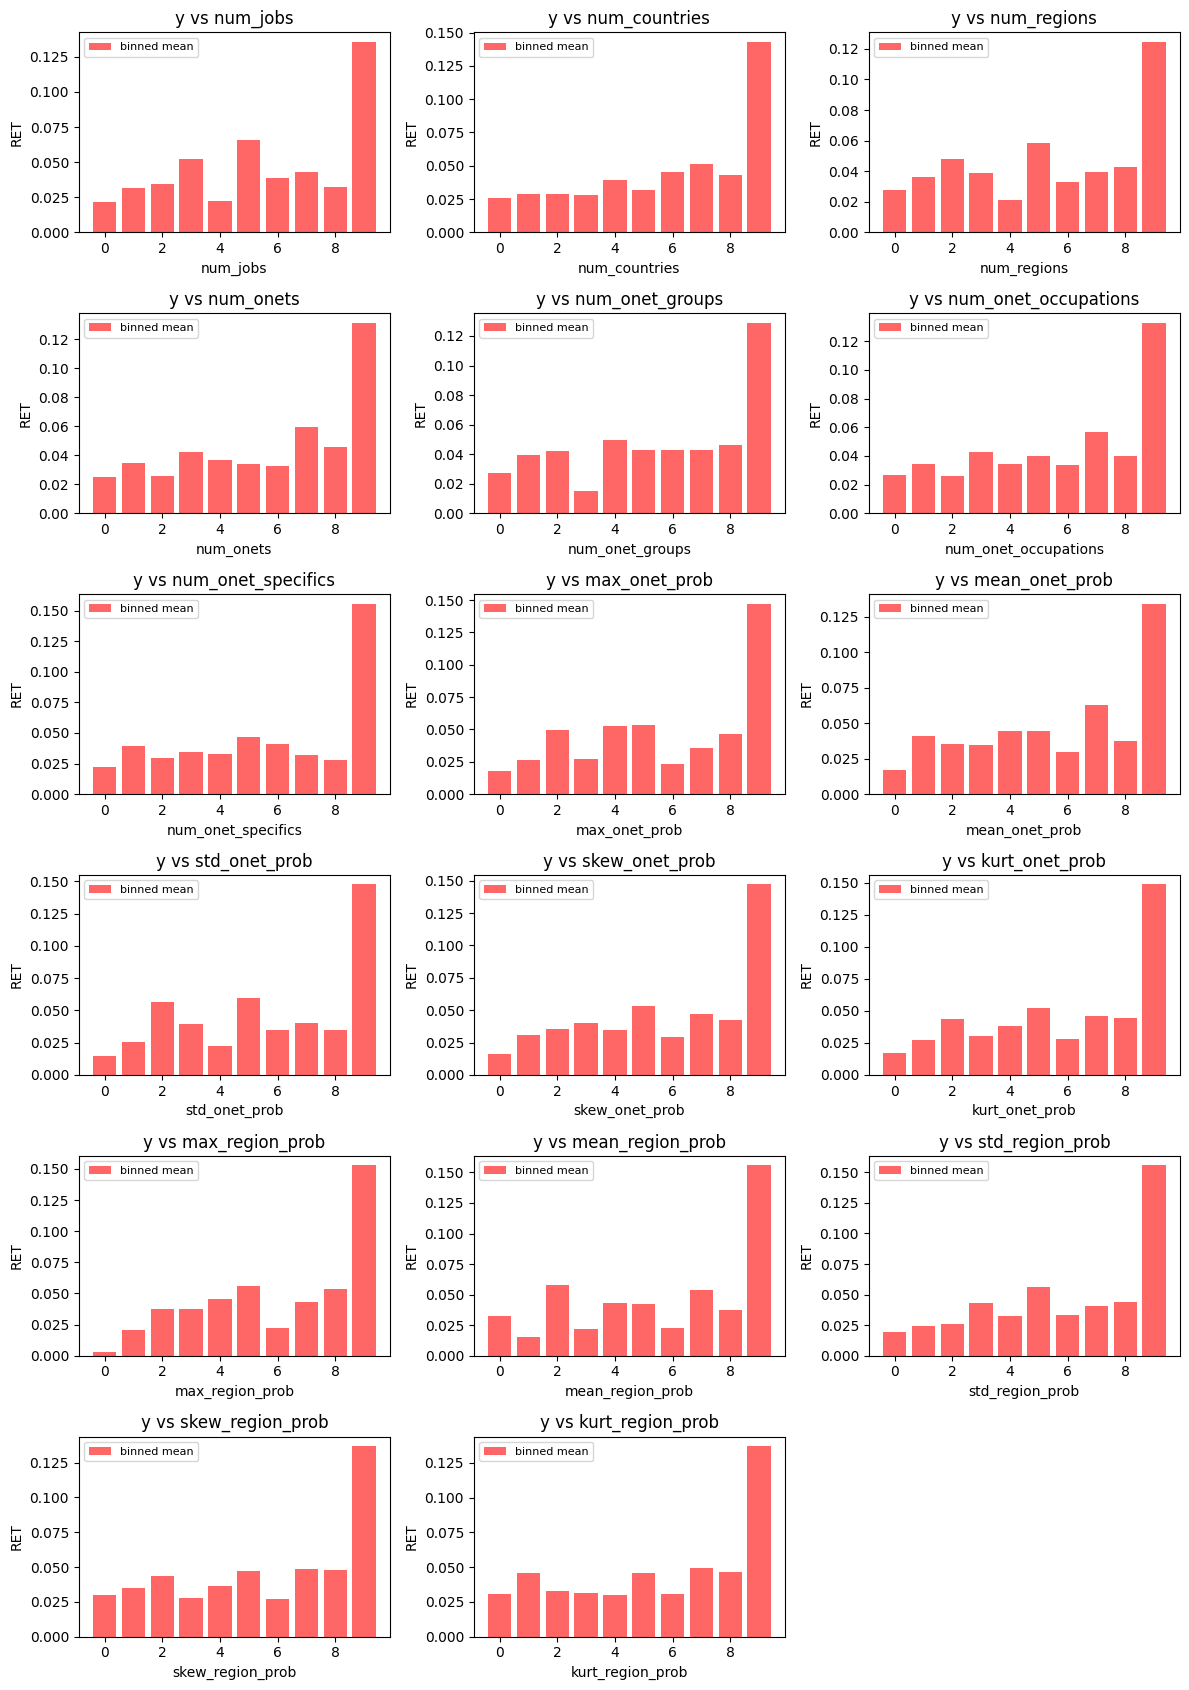

In [38]:
plot_feat_target_bins(x_train,y_train)

<Axes: >

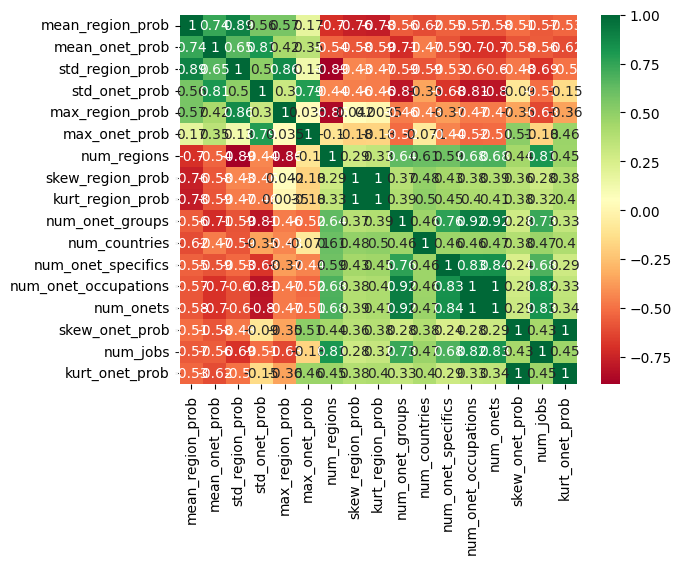

In [387]:
sig_corr = x_train.corr()
order = sig_corr.mean().sort_values(ascending=True).index
sig_corr = sig_corr.loc[order,order]
sns.heatmap(sig_corr,annot=True,cmap='RdYlGn')

In [383]:
model = OLS(y_train,add_constant(x_train))
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    RET   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     124.4
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:44:40   Log-Likelihood:                 34019.
No. Observations:               90338   AIC:                        -6.800e+04
Df Residuals:                   90320   BIC:                        -6.783e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0121      0.001     21.076      0.000       0.011       0.013
num_jobs                -0.0191      0.001    -12.779      0.000      -0.022      -0.016
num_countries           -0.0062      0.001     -5.967      0.000      -0.008      -0.004
num_regions              0.0355      0.002     14.530      0.000       0.031       0.040
num_onets                0.0641      0.007      9.808      0.000       0.051       0.077
num_onet_groups         -0.0060      0.002     -3.736      0.000      -0.009      -0.003
num_onet_occupations    -0.0380      0.006     -6.141      0.000      -0.050      -0.026
num_onet_specifics      -0.0017      0.001     -1.356      0.175      -0.004       0.001
max_onet_prob           -0.0532      0.004    -15.045      0.000      -0.060      -0.046
mean_onet_prob           0.0174      0.002      7.063      0.000       0.013       0.022
std_onet_prob            0.0371      0.004      9.889      0.000       0.030       0.044
skew_onet_prob           0.0529      0.009      6.128      0.000       0.036       0.070
kurt_onet_prob          -0.0077      0.009     -0.885      0.376      -0.025       0.009
max_region_prob         -0.0159      0.003     -4.693      0.000      -0.023      -0.009
mean_region_prob         0.0181      0.004      4.687      0.000       0.011       0.026
std_region_prob          0.0388      0.004      8.723      0.000       0.030       0.048
skew_region_prob         0.0555      0.008      6.826      0.000       0.040       0.071
kurt_region_prob        -0.0261      0.008     -3.331      0.001      -0.042      -0.011
==============================================================================
Omnibus:                    13582.062   Durbin-Watson:                   0.187
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           123372.207
Skew:                           0.445   Prob(JB):                         0.00
Kurtosis:                       8.655   Cond. No.                         65.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [445]:
y_pred = pd.DataFrame({
    'ret': y_test,
    'score': res.predict(add_constant(x_test))
})
y_pred['bin'] = (y_pred.groupby('ts',group_keys=False)['score'].rank(pct=True)*10).clip(upper=9)//1

<Axes: xlabel='bin'>

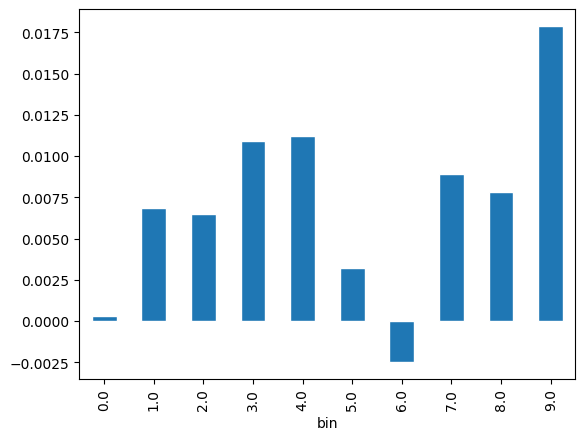

In [446]:
y_pred.groupby(['ts','bin'])['ret'].mean().unstack().mean().plot(kind='bar',edgecolor='white')

In [413]:
y_pred.reset_index().pivot_table(index='ts',columns='bin',values='company_id',aggfunc='nunique')

bin,0.0
ts,
2012-03-14,1
2012-03-15,1
2012-03-16,1
2012-03-19,1
2012-03-20,1
...,...
2017-06-12,120
2017-06-13,120
2017-06-14,120


y_pred